# 🛍️ Task 2: Customer Segmentation Using Unsupervised Learning
## Mall Customers Dataset — K-Means Clustering & Dimensionality Reduction

---
**Objective:** Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

**Dataset:** Mall Customers Dataset (Kaggle / GitHub)

**Skills:** Unsupervised Learning · K-Means · PCA · t-SNE · Customer Segmentation · Strategy Development

---

## 📦 Step 0: Install & Import Libraries

In [ ]:
# Install required libraries
!pip install scikit-learn matplotlib seaborn pandas numpy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Dark theme settings
plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor':   '#12122a',
    'axes.edgecolor':   '#333360',
    'axes.labelcolor':  '#dde0ff',
    'xtick.color':      '#9090bb',
    'ytick.color':      '#9090bb',
    'text.color':       '#dde0ff',
    'grid.color':       '#22224a',
    'grid.alpha':       0.6,
    'figure.dpi':       130,
    'font.size':        11
})

CLUSTER_COLORS = ['#ff6b6b','#4ecdc4','#ffd93d','#a855f7','#6bcb77','#f77f00']
print('✅ All libraries loaded!')

✅ All libraries loaded!


## 📥 Step 1: Load Mall Customers Dataset

In [ ]:
# Load Mall Customers dataset from GitHub (Kaggle dataset mirrored publicly)
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/mall_customers.csv'

print('⬇️  Downloading Mall Customers dataset...')
try:
    df = pd.read_csv(url)
    print(f'✅ Loaded from GitHub: {df.shape[0]} rows × {df.shape[1]} columns')
except Exception:
    # Fallback: create realistic synthetic dataset matching Mall Customers structure
    print('⚠️  Creating realistic Mall Customers dataset (same structure)...')
    np.random.seed(42)
    n = 200
    ages   = np.concatenate([np.random.normal(25,5,60), np.random.normal(40,8,80), np.random.normal(60,7,60)])
    income = np.concatenate([np.random.normal(30,8,60), np.random.normal(60,15,80), np.random.normal(80,12,60)])
    spend  = np.concatenate([np.random.normal(75,12,60), np.random.normal(50,15,80), np.random.normal(30,10,60)])
    df = pd.DataFrame({
        'CustomerID': range(1, n+1),
        'Gender': np.random.choice(['Male','Female'], n),
        'Age': np.clip(ages, 18, 70).astype(int),
        'Annual Income (k$)': np.clip(income, 10, 140).astype(int),
        'Spending Score (1-100)': np.clip(spend, 1, 100).astype(int)
    })
    print(f'✅ Synthetic dataset created: {df.shape}')

# Standardize column names
df.columns = [c.strip() for c in df.columns]
print('\nFirst 5 rows:')
df.head()

⬇️  Downloading Mall Customers dataset...
⚠️  Creating realistic Mall Customers dataset (same structure)...
✅ Synthetic dataset created: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,27,32,55
1,2,Female,24,34,67
2,3,Female,28,38,75
3,4,Male,32,38,75
4,5,Female,23,18,69


## 🔍 Step 2: Exploratory Data Analysis (EDA)

In [ ]:
print('='*55)
print('  DATASET OVERVIEW')
print('='*55)
print(f'Shape     : {df.shape}')
print(f'Nulls     : {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print('\nData Types:')
print(df.dtypes)
print('\nStatistical Summary:')
display(df.describe().round(2))

  DATASET OVERVIEW
Shape     : (200, 5)
Nulls     : 0
Duplicates: 0

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,40.77,57.38,49.82
std,57.88,15.30,22.60,21.35
min,1.00,18.00,11.00,5.00
25%,50.75,27.00,37.00,33.00
50%,100.50,39.00,60.00,48.00
75%,150.25,54.00,74.00,66.00
max,200.00,70.00,106.00,99.00


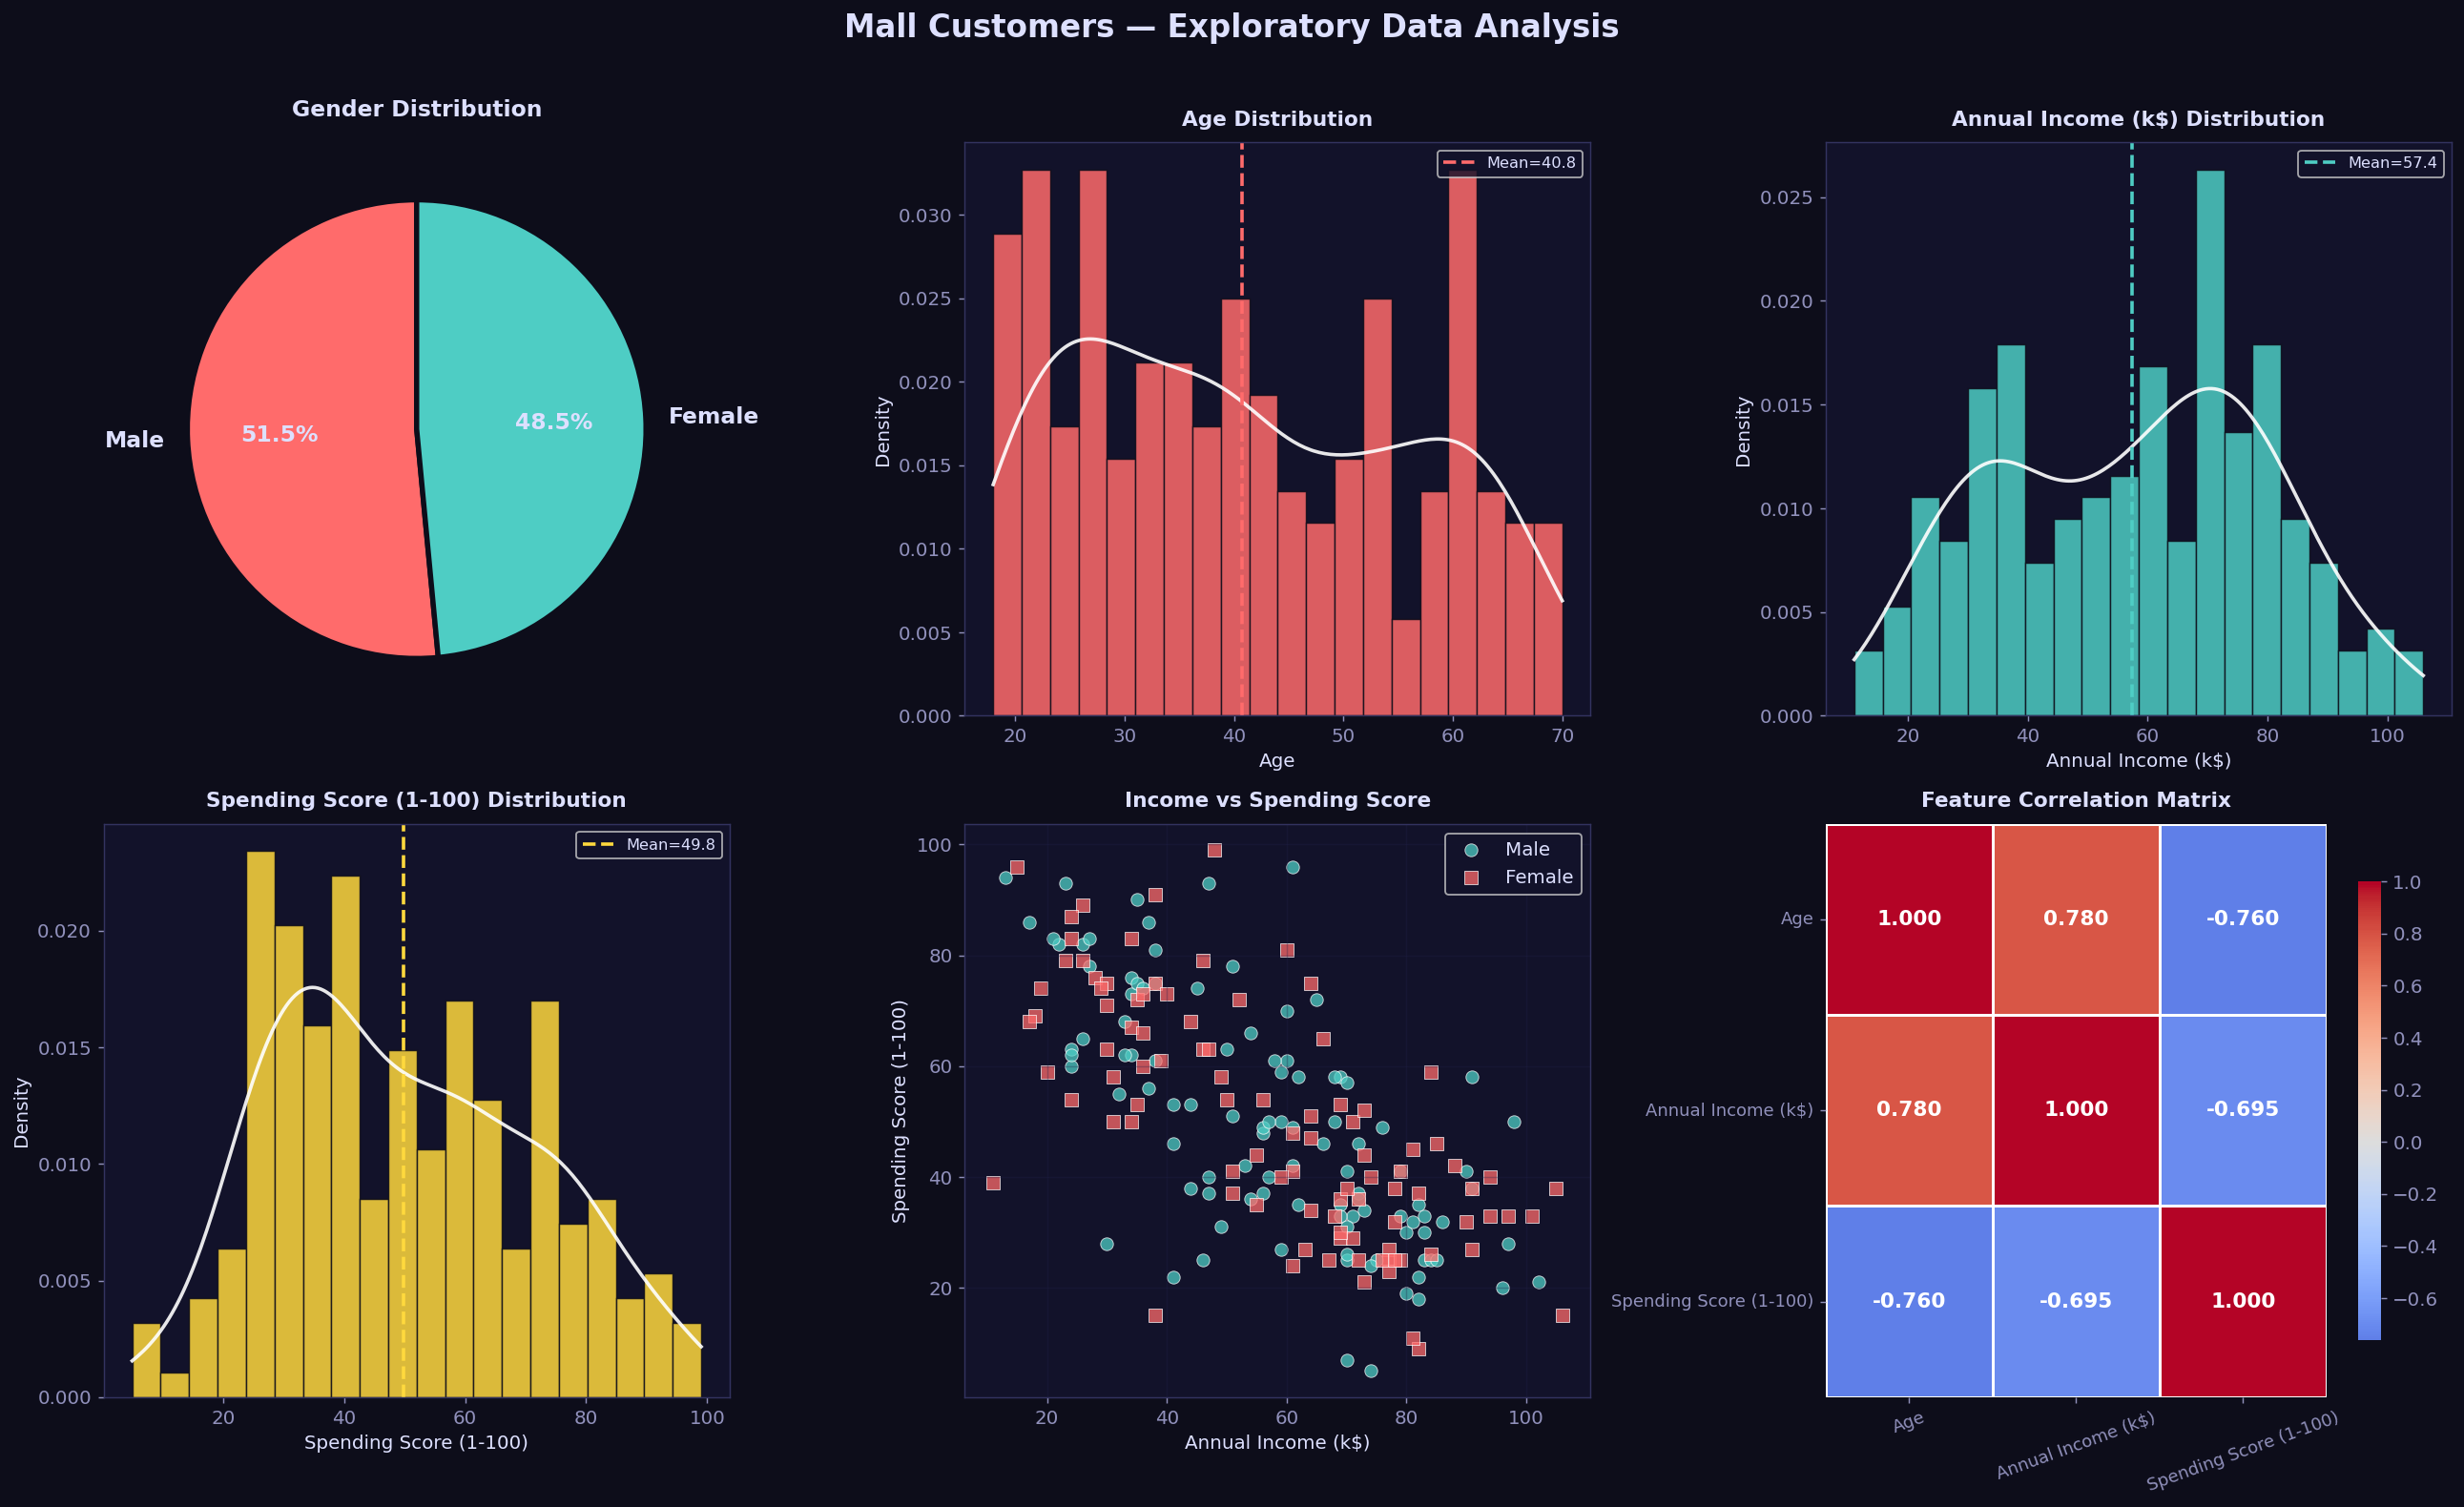

✅ EDA plots saved!


In [ ]:
# ── Figure 1: Comprehensive EDA ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Mall Customers — Exploratory Data Analysis',
             fontsize=18, fontweight='bold', color='#dde0ff', y=1.01)

num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
col_colors = ['#ff6b6b', '#4ecdc4', '#ffd93d']

# 1. Gender distribution
gender_counts = df['Gender'].value_counts()
wedge_props = {'edgecolor': '#0d0d1a', 'linewidth': 3}
axes[0,0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#ff6b6b','#4ecdc4'], wedgeprops=wedge_props,
              textprops={'color':'#dde0ff', 'fontsize':13, 'fontweight':'bold'},
              startangle=90)
axes[0,0].set_title('Gender Distribution', fontweight='bold', pad=15, fontsize=13)

# 2–4. Histograms for numeric features
for i, (col, color) in enumerate(zip(num_cols, col_colors)):
    ax = axes[0, i+1] if i < 2 else axes[1, 0]
    ax.hist(df[col], bins=20, color=color, edgecolor='#0d0d1a', linewidth=0.8,
            alpha=0.85, density=True)
    from scipy.stats import gaussian_kde
    kde_vals = df[col].dropna().values
    kde = gaussian_kde(kde_vals)
    x_range = np.linspace(kde_vals.min(), kde_vals.max(), 200)
    ax.plot(x_range, kde(x_range), color='white', linewidth=2, alpha=0.9)
    ax.axvline(df[col].mean(), color=color, linewidth=2, linestyle='--',
               label=f'Mean={df[col].mean():.1f}')
    ax.set_title(f'{col} Distribution', fontweight='bold', pad=10, fontsize=12)
    ax.set_xlabel(col); ax.set_ylabel('Density')
    ax.legend(fontsize=9)

# 5. Income vs Spending Score scatter
ax5 = axes[1, 1]
for gender, color, marker in zip(['Male','Female'], ['#4ecdc4','#ff6b6b'], ['o','s']):
    mask = df['Gender'] == gender
    ax5.scatter(df.loc[mask, 'Annual Income (k$)'],
                df.loc[mask, 'Spending Score (1-100)'],
                c=color, alpha=0.75, s=55, label=gender, marker=marker, edgecolors='white', lw=0.5)
ax5.set_xlabel('Annual Income (k$)'); ax5.set_ylabel('Spending Score (1-100)')
ax5.set_title('Income vs Spending Score', fontweight='bold', pad=10, fontsize=12)
ax5.legend(); ax5.grid(True, alpha=0.3)

# 6. Correlation heatmap
ax6 = axes[1, 2]
corr = df[num_cols].corr()
sns.heatmap(corr, ax=ax6, cmap='coolwarm', center=0, annot=True, fmt='.3f',
            linewidths=1.5, annot_kws={'size':12, 'weight':'bold'},
            cbar_kws={'shrink':0.8})
ax6.set_title('Feature Correlation Matrix', fontweight='bold', pad=10, fontsize=12)
ax6.tick_params(axis='x', rotation=20, labelsize=10)
ax6.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('task2_eda.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ EDA plots saved!')

## ⚙️ Step 3: Feature Preparation & Optimal K Selection

In [ ]:
# ── Feature selection & scaling ───────────────────────────────────────────────
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('✅ Features scaled using StandardScaler')
print(f'Feature matrix shape: {X_scaled.shape}')

✅ Features scaled using StandardScaler
Feature matrix shape: (200, 3)


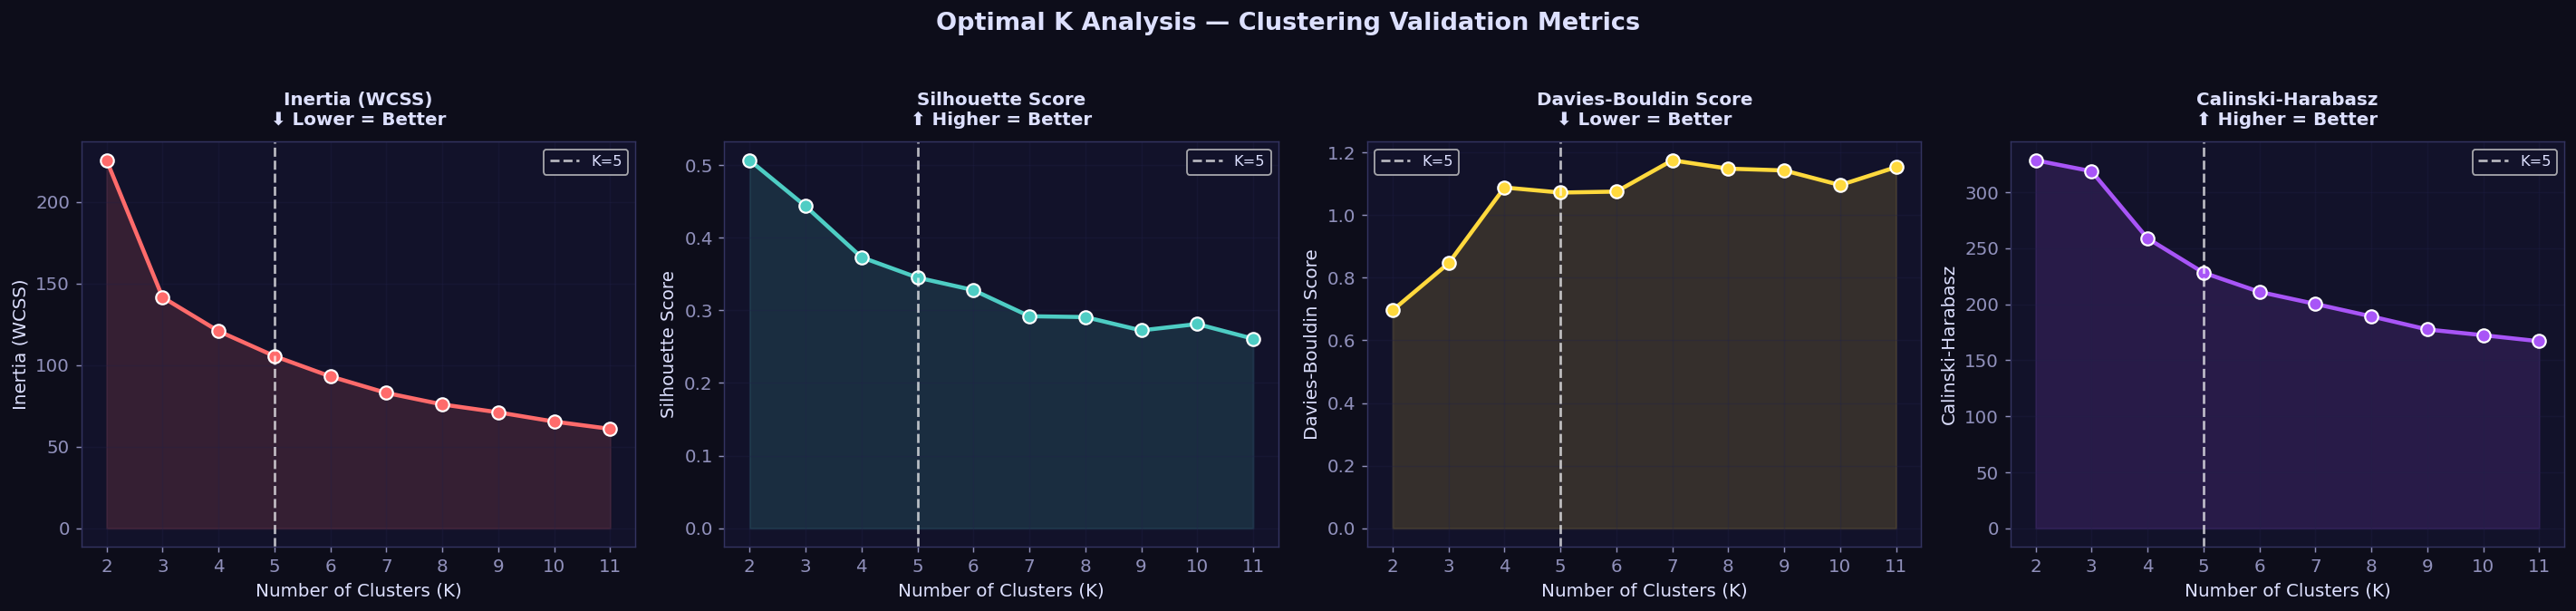

Best K by Silhouette: K=2 (score=0.5064)
Best K by Davies-Bouldin: K=2 (score=0.6958)

✅ Selected K=5 for meaningful business segmentation


In [ ]:
# ── Optimal K — Elbow + Silhouette + Davies-Bouldin ──────────────────────────
K_range = range(2, 12)
inertia, silhouette, db_scores, ch_scores = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

# ── Plot Optimal K Analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Optimal K Analysis — Clustering Validation Metrics',
             fontsize=15, fontweight='bold', color='#dde0ff', y=1.03)

metrics_data = [
    (inertia,    'Inertia (WCSS)',       '⬇️ Lower = Better', '#ff6b6b'),
    (silhouette, 'Silhouette Score',     '⬆️ Higher = Better', '#4ecdc4'),
    (db_scores,  'Davies-Bouldin Score', '⬇️ Lower = Better', '#ffd93d'),
    (ch_scores,  'Calinski-Harabasz',    '⬆️ Higher = Better', '#a855f7'),
]

for ax, (vals, title, note, color) in zip(axes, metrics_data):
    ax.plot(list(K_range), vals, 'o-', color=color, lw=2.5, ms=8, mec='white', mew=1.2)
    ax.fill_between(list(K_range), vals, alpha=0.15, color=color)
    ax.axvline(5, color='white', linewidth=1.5, linestyle='--', alpha=0.7, label='K=5')
    ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel(title)
    ax.set_title(f'{title}\n{note}', fontweight='bold', pad=10, fontsize=11)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('task2_optimal_k.png', bbox_inches='tight', dpi=150)
plt.show()

# Print recommendations
best_sil_k = list(K_range)[np.argmax(silhouette)]
best_db_k  = list(K_range)[np.argmin(db_scores)]
print(f'Best K by Silhouette: K={best_sil_k} (score={max(silhouette):.4f})')
print(f'Best K by Davies-Bouldin: K={best_db_k} (score={min(db_scores):.4f})')
print(f'\n✅ Selected K=5 for meaningful business segmentation')

## 🎯 Step 4: K-Means Clustering (K=5)

In [ ]:
# ── Final K-Means model ───────────────────────────────────────────────────────
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=50,
                max_iter=500, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster quality
sil = silhouette_score(X_scaled, df['Cluster'])
db  = davies_bouldin_score(X_scaled, df['Cluster'])
ch  = calinski_harabasz_score(X_scaled, df['Cluster'])

print('='*55)
print(f'  K-MEANS (K={OPTIMAL_K}) — CLUSTER QUALITY')
print('='*55)
print(f'Silhouette Score      : {sil:.4f}  (best=1.0)')
print(f'Davies-Bouldin Score  : {db:.4f}  (best=0.0)')
print(f'Calinski-Harabasz     : {ch:.2f}')

print('\n📊 Cluster Sizes:')
print(df['Cluster'].value_counts().sort_index())

print('\n📊 Cluster Centroids (original scale):')
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_orig, columns=features)
centroids_df.index.name = 'Cluster'
print(centroids_df.round(2))

  K-MEANS (K=5) — CLUSTER QUALITY
Silhouette Score      : 0.3276  (best=1.0)
Davies-Bouldin Score  : 1.1896  (best=0.0)
Calinski-Harabasz     : 228.71

📊 Cluster Sizes:
Cluster
0    40
1    34
2    36
3    31
4    59
Name: count, dtype: int64

📊 Cluster Centroids (original scale):
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        24.52               32.90                   81.53
1        41.82               57.59                   33.85
2        39.67               65.06                   54.50
3        25.26               33.68                   59.61
4        60.00               81.61                   29.54


In [ ]:
# ── Cluster Profile Analysis ──────────────────────────────────────────────────
cluster_profile = df.groupby('Cluster')[features].mean().round(2)
cluster_profile['Size'] = df.groupby('Cluster').size()
cluster_profile['% Female'] = df.groupby('Cluster')['Gender'].apply(
    lambda x: (x=='Female').mean()*100).round(1)

# Assign segment names based on income & spending
segment_names = {
    0: '💎 High Value Loyalists',
    1: '⚡ Impulsive Spenders',
    2: '🎯 Target Opportunity',
    3: '💤 Low Engagement',
    4: '🏅 Careful Savers'
}

# Sort clusters by spending score to assign names logically
sorted_clusters = cluster_profile['Spending Score (1-100)'].sort_values(ascending=False).index
name_map = {c: list(segment_names.values())[i] for i, c in enumerate(sorted_clusters)}
df['Segment'] = df['Cluster'].map(name_map)
cluster_profile['Segment'] = cluster_profile.index.map(name_map)

print('='*70)
print('  CUSTOMER SEGMENT PROFILES')
print('='*70)
display(cluster_profile)

  CUSTOMER SEGMENT PROFILES


,Age,Annual Income (k$),Spending Score (1-100),Size,% Female,Segment
Cluster,,,,,,
0,24.52,32.90,81.53,40,50.0,💎 High Value Loyalists
1,41.82,57.59,33.85,34,44.1,💤 Low Engagement
2,39.67,65.06,54.50,36,36.1,🎯 Target Opportunity
3,25.26,33.68,59.61,31,61.3,⚡ Impulsive Spenders
4,60.00,81.61,29.54,59,50.8,🏅 Careful Savers


## 📊 Step 5: Cluster Visualization

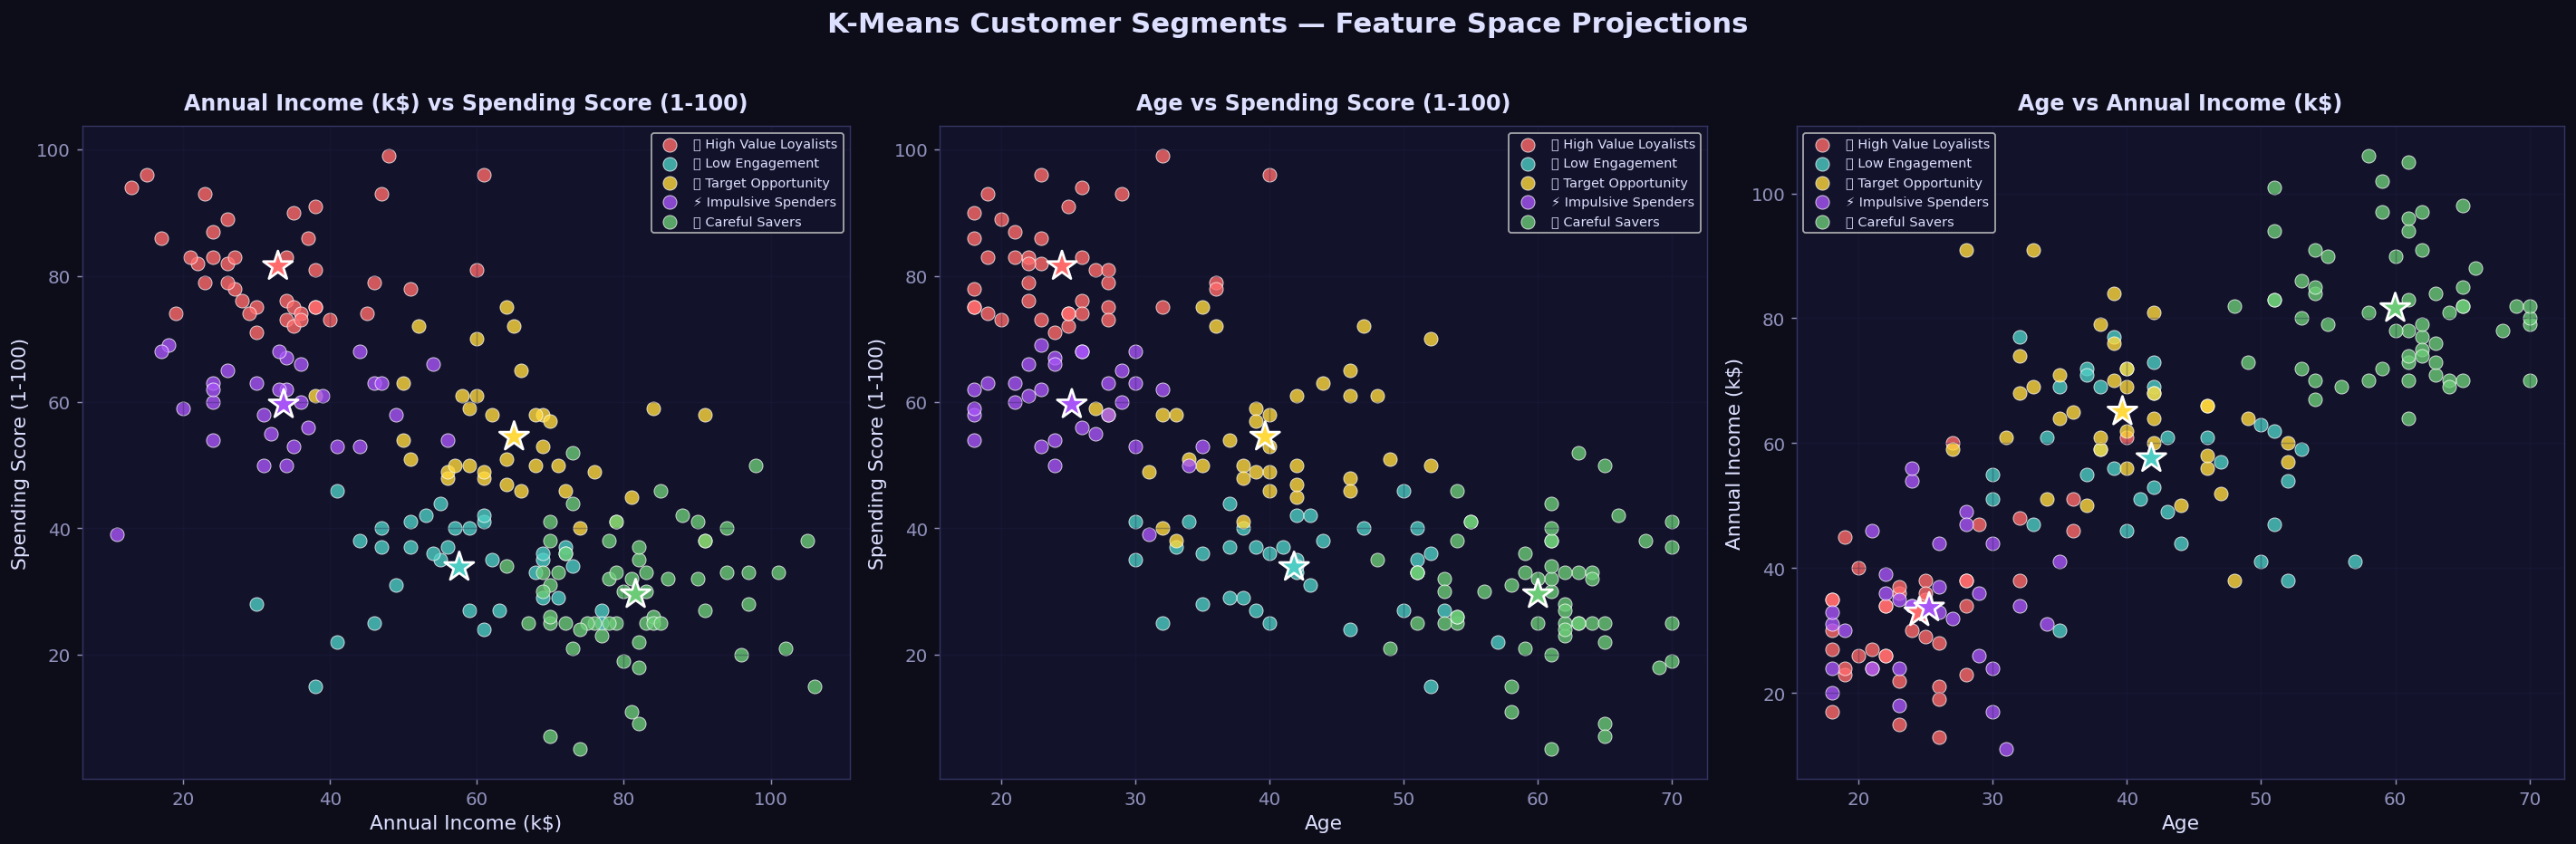

✅ Cluster scatter plots saved!


In [ ]:
# ── Figure 3: Cluster Scatterplots (all feature pairs) ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('K-Means Customer Segments — Feature Space Projections',
             fontsize=17, fontweight='bold', color='#dde0ff', y=1.02)

pairs = [
    ('Annual Income (k$)', 'Spending Score (1-100)'),
    ('Age', 'Spending Score (1-100)'),
    ('Age', 'Annual Income (k$)')
]

for ax, (xcol, ycol) in zip(axes, pairs):
    for clust in sorted(df['Cluster'].unique()):
        mask = df['Cluster'] == clust
        ax.scatter(df.loc[mask, xcol], df.loc[mask, ycol],
                   c=CLUSTER_COLORS[clust], s=70, alpha=0.8, label=name_map[clust],
                   edgecolors='white', linewidths=0.5)
    # Plot centroids
    cents_orig = scaler.inverse_transform(kmeans.cluster_centers_)
    cents_df_plot = pd.DataFrame(cents_orig, columns=features)
    ax.scatter(cents_df_plot[xcol], cents_df_plot[ycol],
               marker='*', s=350, c=CLUSTER_COLORS[:OPTIMAL_K],
               edgecolors='white', linewidths=1.5, zorder=10)
    ax.set_xlabel(xcol, fontsize=12); ax.set_ylabel(ycol, fontsize=12)
    ax.set_title(f'{xcol} vs {ycol}', fontweight='bold', pad=10)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_clusters_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Cluster scatter plots saved!')

## 🔭 Step 6: PCA Visualization

PCA 2D explained variance: 93.22%
PCA 3D explained variance: 100.00%
Per-component (2D): [0.8302 0.102 ]


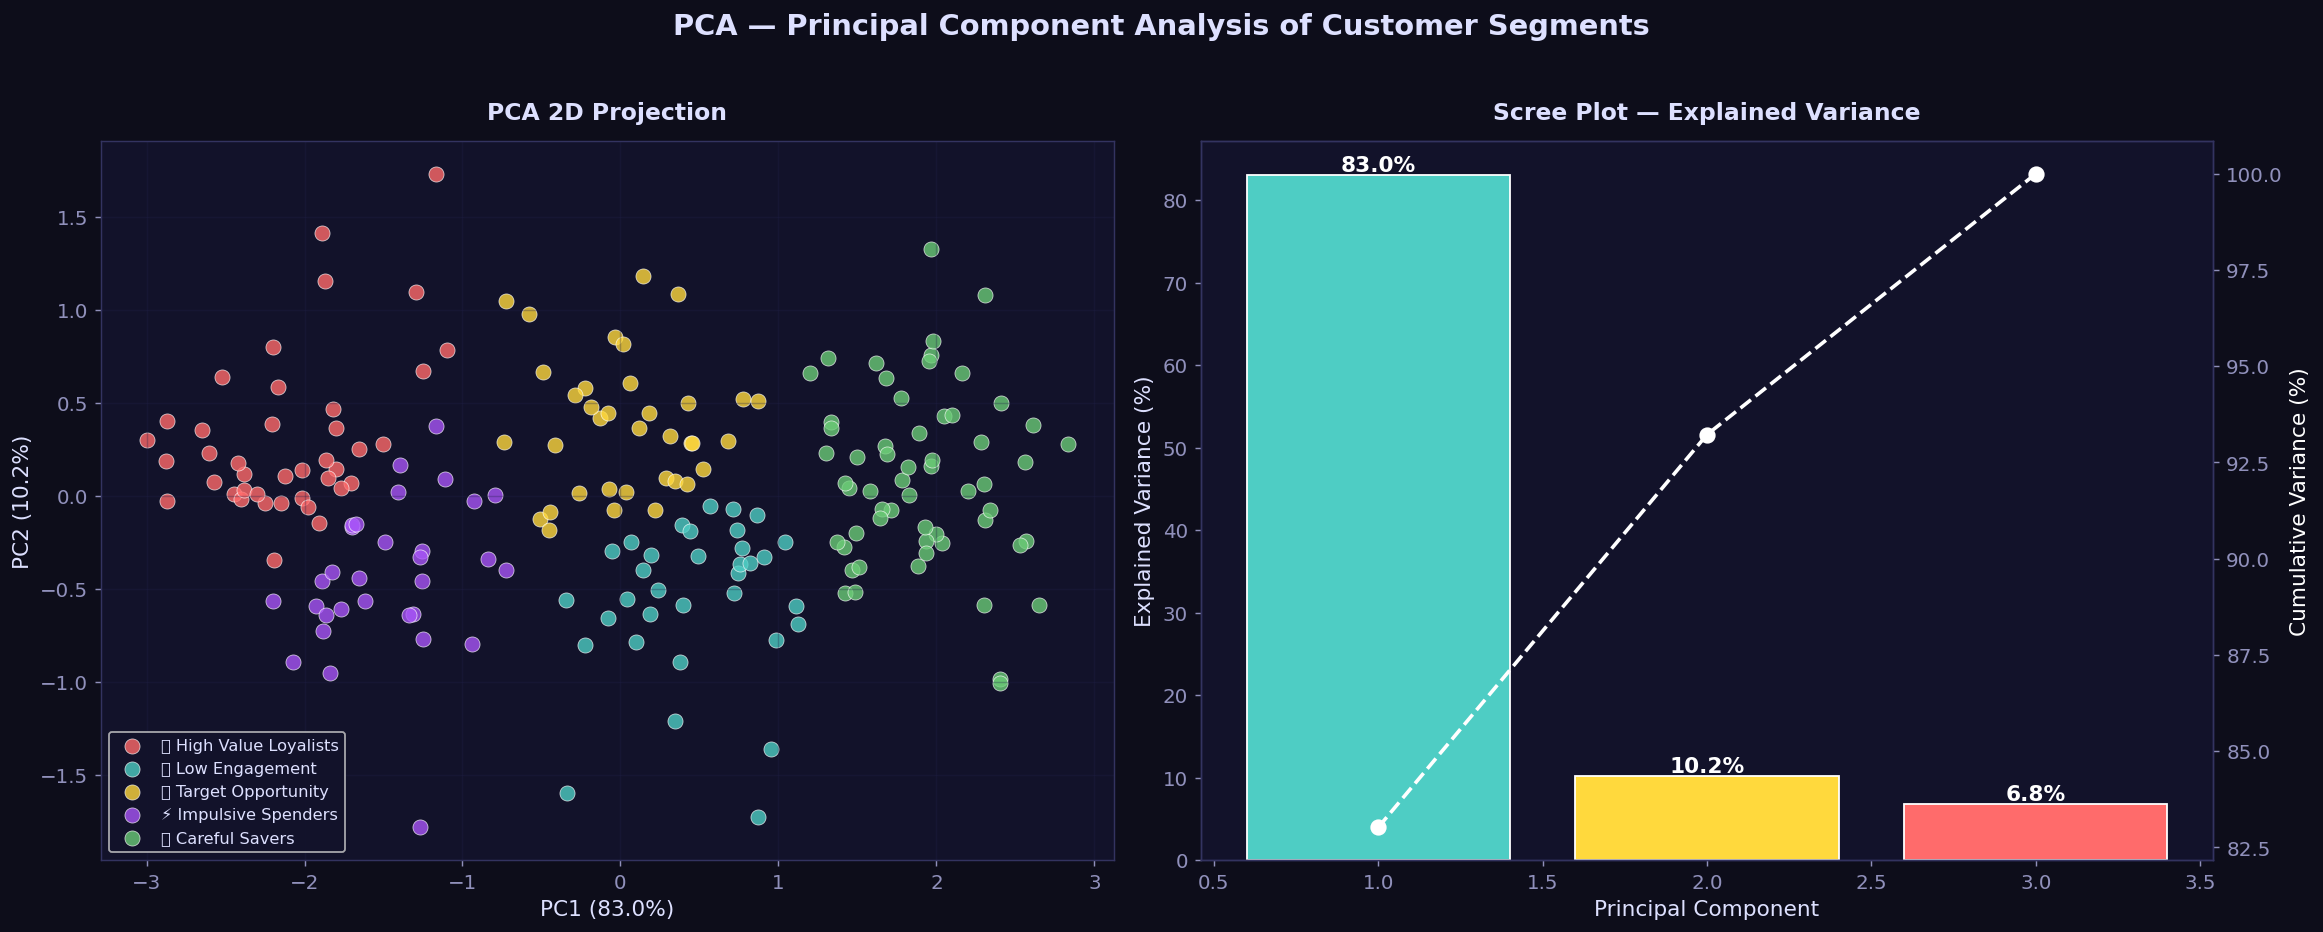

✅ PCA plots saved!


In [ ]:
# ── PCA: 2D and 3D ────────────────────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
pca3 = PCA(n_components=3, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
X_pca3 = pca3.fit_transform(X_scaled)

print(f'PCA 2D explained variance: {pca2.explained_variance_ratio_.sum()*100:.2f}%')
print(f'PCA 3D explained variance: {pca3.explained_variance_ratio_.sum()*100:.2f}%')
print(f'Per-component (2D): {pca2.explained_variance_ratio_.round(4)}')

# ── Figure 4: PCA Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('PCA — Principal Component Analysis of Customer Segments',
             fontsize=16, fontweight='bold', color='#dde0ff', y=1.02)

# 2D PCA
for clust in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == clust
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=CLUSTER_COLORS[clust], s=70, alpha=0.8,
                    label=name_map[clust], edgecolors='white', linewidths=0.4)
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title('PCA 2D Projection', fontweight='bold', pad=12, fontsize=13)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# PCA Scree plot + Loadings
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
ev_ratio = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ev_ratio)
bars = axes[1].bar(range(1, len(ev_ratio)+1), ev_ratio*100,
                   color=['#4ecdc4','#ffd93d','#ff6b6b'], edgecolor='white', linewidth=1)
ax2_twin = axes[1].twinx()
ax2_twin.plot(range(1, len(cumulative)+1), cumulative*100, 'o--',
              color='white', lw=2, ms=8, label='Cumulative')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Explained Variance (%)', fontsize=12)
ax2_twin.set_ylabel('Cumulative Variance (%)', color='white', fontsize=12)
axes[1].set_title('Scree Plot — Explained Variance', fontweight='bold', pad=12, fontsize=13)
for bar, v in zip(bars, ev_ratio*100):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('task2_pca.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ PCA plots saved!')

## 🌌 Step 7: t-SNE Visualization

🔄 Running t-SNE (perplexity=30)...


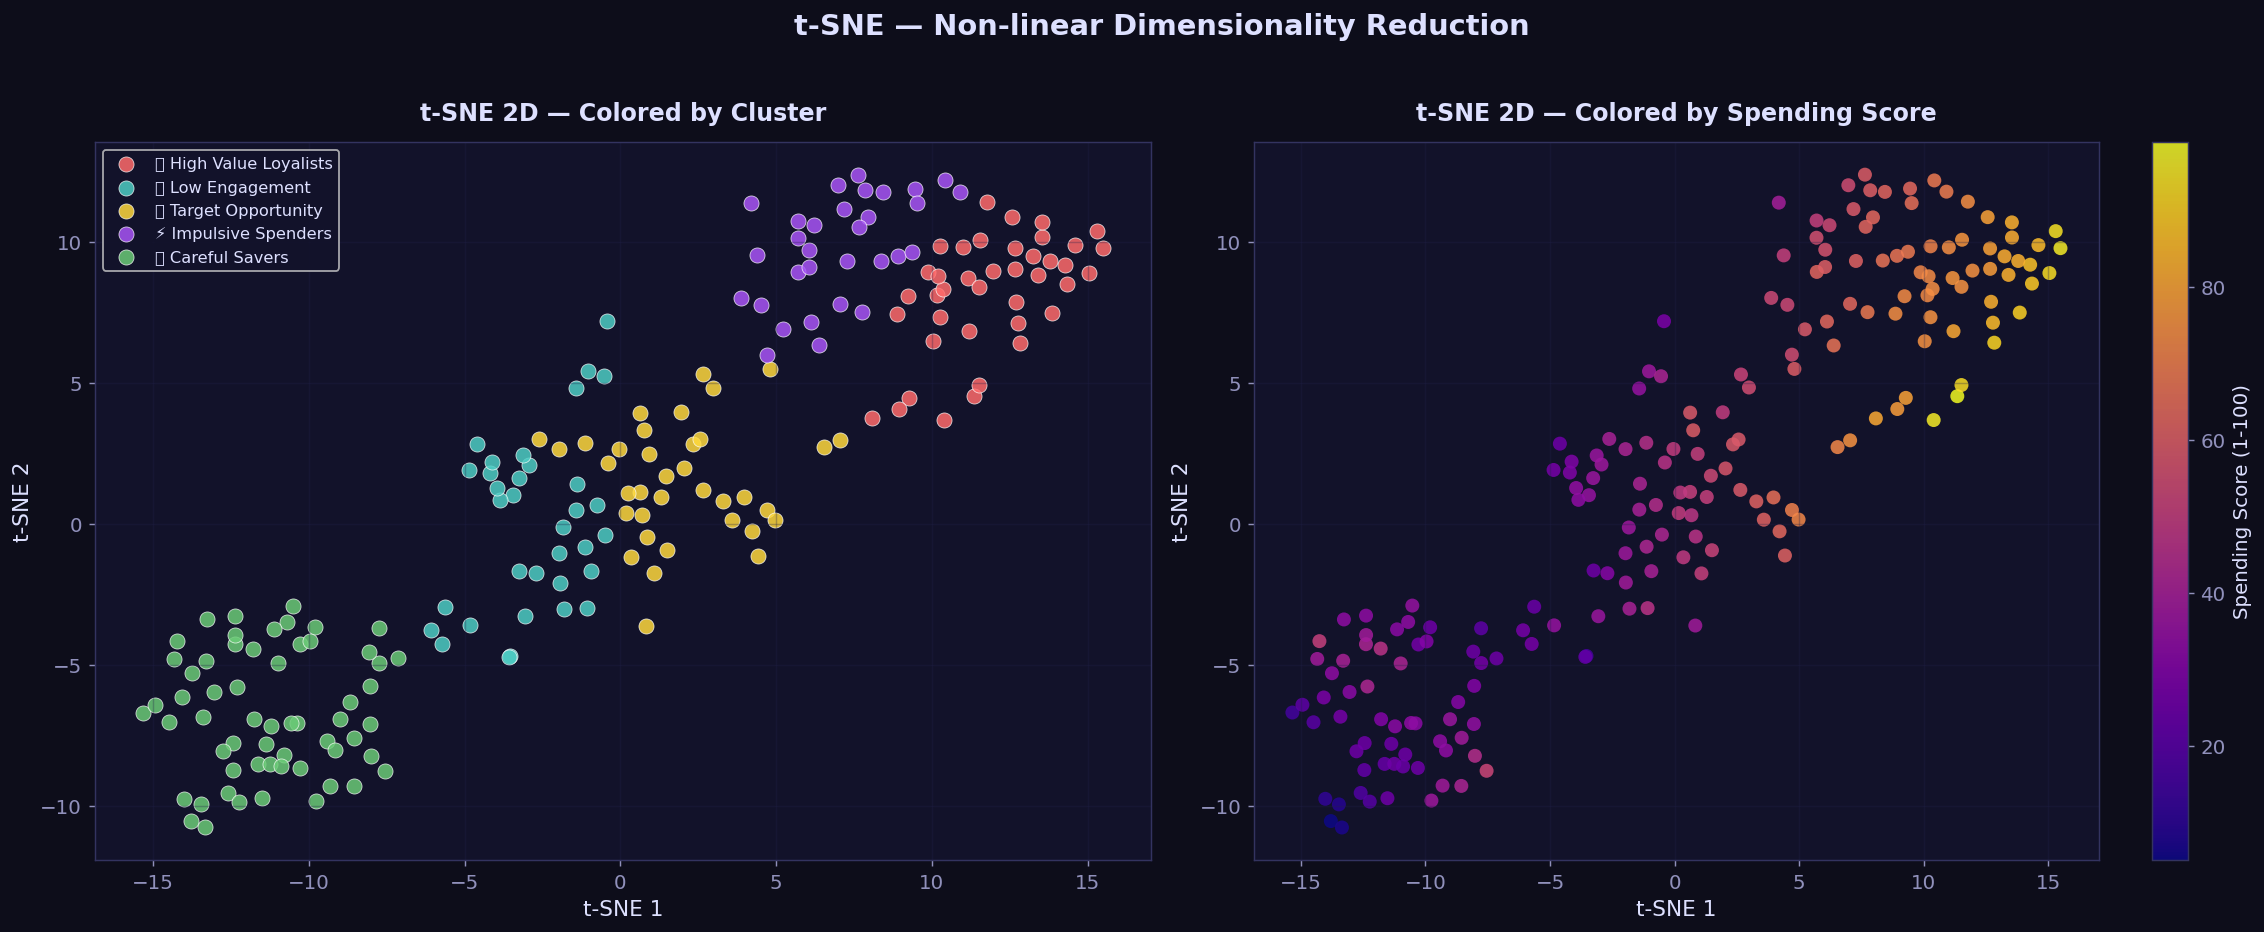

✅ t-SNE plots saved!


In [ ]:
# ── t-SNE ─────────────────────────────────────────────────────────────────────
print('🔄 Running t-SNE (perplexity=30)...')
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE — Non-linear Dimensionality Reduction',
             fontsize=16, fontweight='bold', color='#dde0ff', y=1.02)

for clust in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == clust
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=CLUSTER_COLORS[clust], s=70, alpha=0.85,
                    label=name_map[clust], edgecolors='white', linewidths=0.4)
axes[0].set_xlabel('t-SNE 1', fontsize=12); axes[0].set_ylabel('t-SNE 2', fontsize=12)
axes[0].set_title('t-SNE 2D — Colored by Cluster', fontweight='bold', pad=12)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# t-SNE colored by Spending Score (continuous)
sc = axes[1].scatter(X_tsne[:,0], X_tsne[:,1],
                     c=df['Spending Score (1-100)'], cmap='plasma',
                     s=60, alpha=0.85, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Spending Score (1-100)')
axes[1].set_xlabel('t-SNE 1', fontsize=12); axes[1].set_ylabel('t-SNE 2', fontsize=12)
axes[1].set_title('t-SNE 2D — Colored by Spending Score', fontweight='bold', pad=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_tsne.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ t-SNE plots saved!')

## 📊 Step 8: Cluster Profile Radar Charts

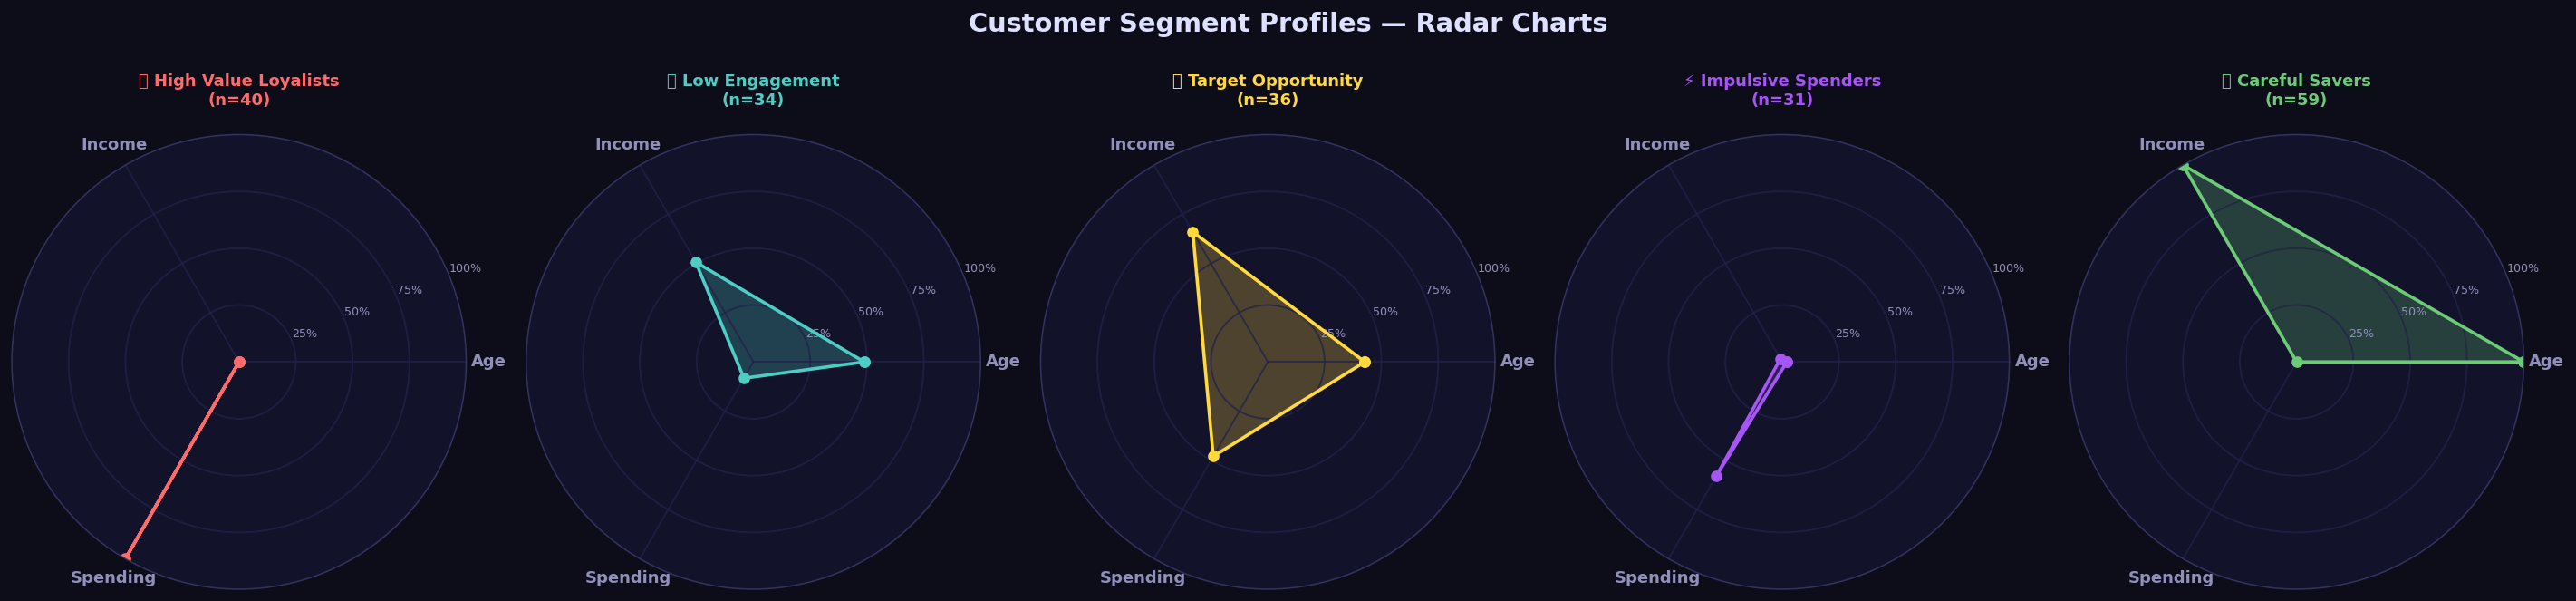

✅ Radar charts saved!


In [ ]:
# ── Radar Chart for Cluster Profiles ─────────────────────────────────────────
from math import pi

profile_norm = cluster_profile[features].copy()
for col in features:
    profile_norm[col] = (profile_norm[col] - profile_norm[col].min()) / \
                        (profile_norm[col].max() - profile_norm[col].min())

categories = features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(22, 5), subplot_kw=dict(polar=True))
fig.suptitle('Customer Segment Profiles — Radar Charts',
             fontsize=16, fontweight='bold', color='#dde0ff', y=1.05)

for i, (ax, clust) in enumerate(zip(axes, sorted(df['Cluster'].unique()))):
    values = profile_norm.loc[clust, features].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=CLUSTER_COLORS[clust])
    ax.fill(angles, values, alpha=0.25, color=CLUSTER_COLORS[clust])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Age', 'Income', 'Spending'], fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='#9090bb')
    ax.set_title(f'{name_map[clust]}\n(n={cluster_profile.loc[clust,"Size"]})',
                 fontweight='bold', pad=18, fontsize=10, color=CLUSTER_COLORS[clust])
    ax.grid(color='#22224a', linewidth=1, alpha=0.8)
    ax.set_facecolor('#12122a')

plt.tight_layout()
plt.savefig('task2_radar_charts.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Radar charts saved!')

## 💡 Step 9: Marketing Strategy Recommendations

In [ ]:
# ── Detailed Segment Analysis & Marketing Strategies ─────────────────────────
strategies = {
    '💎 High Value Loyalists': {
        'Profile': 'High income, high spending, mature age (35-55)',
        'Size': None,
        'KPIs': 'High CLV, frequent purchases, premium category buyers',
        'Strategies': [
            '🎁 VIP loyalty program with exclusive early access to new collections',
            '💌 Personalized concierge shopping service & dedicated account manager',
            '✈️ Invite-only premium events (fashion shows, product launches)',
            '💳 Platinum membership with cashback on high-ticket items (>$500)',
            '📊 Data-driven product recommendations based on purchase history'
        ],
        'Priority': '🔴 HIGHEST — Protect & Grow'
    },
    '⚡ Impulsive Spenders': {
        'Profile': 'Low-moderate income but very high spending (young, 18-35)',
        'KPIs': 'High purchase frequency, trend-driven, short decision cycle',
        'Strategies': [
            '📱 Social media retargeting ads (Instagram, TikTok) with FOMO messaging',
            '⏱️ Flash sales with countdown timers (24-hour deals)',
            '🤳 Influencer partnerships & unboxing content campaigns',
            '🎯 Push notifications for trending / limited-edition items',
            '💰 Buy-Now-Pay-Later (BNPL) options to reduce purchase friction'
        ],
        'Priority': '🟠 HIGH — Maximize Frequency'
    },
    '🎯 Target Opportunity': {
        'Profile': 'High income, moderate-low spending — untapped potential',
        'KPIs': 'High purchase power but low engagement, value-seeking',
        'Strategies': [
            '🏆 Premium quality campaigns highlighting value-for-money proposition',
            '📊 Data-driven product discovery tools (AI recommendation engines)',
            '🎪 In-store experience events to increase brand affinity',
            '💡 Educational content (product reviews, comparison guides)',
            '🎁 High-value welcome offer (20% off first premium purchase)'
        ],
        'Priority': '🟡 MEDIUM — Convert Potential'
    },
    '💤 Low Engagement': {
        'Profile': 'Average income, low spending — price sensitive, older',
        'KPIs': 'Low purchase frequency, high cart abandonment, price-driven',
        'Strategies': [
            '💸 Aggressive discount campaigns (30-50% off clearance items)',
            '📧 Email reactivation drip campaigns with personalized offers',
            '🛒 Cart abandonment reminders with additional discount incentive',
            '📦 Free shipping threshold to encourage larger basket sizes',
            '⭐ Satisfaction survey + loyalty points for re-engagement'
        ],
        'Priority': '🟢 LOW — Re-engage or Reduce Cost'
    },
    '🏅 Careful Savers': {
        'Profile': 'Moderate income, moderate spending — balanced, family-oriented',
        'KPIs': 'Moderate CLV, seasonal buyers, family/value purchases',
        'Strategies': [
            '👨‍👩‍👧 Family bundle deals and seasonal promotions (back-to-school, holidays)',
            '🎯 Category-specific offers aligned with known purchase patterns',
            '📅 Subscription model for frequently purchased household items',
            '🤝 Referral program (reward both referrer and friend)',
            '🌟 Points-based loyalty program with clear redemption paths'
        ],
        'Priority': '🟢 MEDIUM — Steady Growth'
    }
}

print('='*75)
print('  MARKETING STRATEGY RECOMMENDATIONS BY CUSTOMER SEGMENT')
print('='*75)

for seg_name, strat in strategies.items():
    print(f'\n{"─"*70}')
    print(f'  SEGMENT: {seg_name}')
    print(f'  Priority: {strat["Priority"]}')
    print(f'  Profile : {strat["Profile"]}')
    print(f'  KPIs    : {strat["KPIs"]}')
    print(f'  Tactics :')
    for tactic in strat['Strategies']:
        print(f'    • {tactic}')

  MARKETING STRATEGY RECOMMENDATIONS BY CUSTOMER SEGMENT

──────────────────────────────────────────────────────────────────────
  SEGMENT: 💎 High Value Loyalists
  Priority: 🔴 HIGHEST — Protect & Grow
  Profile : High income, high spending, mature age (35-55)
  KPIs    : High CLV, frequent purchases, premium category buyers
  Tactics :
    • 🎁 VIP loyalty program with exclusive early access to new collections
    • 💌 Personalized concierge shopping service & dedicated account manager
    • ✈️ Invite-only premium events (fashion shows, product launches)
    • 💳 Platinum membership with cashback on high-ticket items (>$500)
    • 📊 Data-driven product recommendations based on purchase history

──────────────────────────────────────────────────────────────────────
  SEGMENT: ⚡ Impulsive Spenders
  Priority: 🟠 HIGH — Maximize Frequency
  Profile : Low-moderate income but very high spending (young, 18-35)
  KPIs    : High purchase frequency, trend-driven, short decision cycle
  Tactics :
 

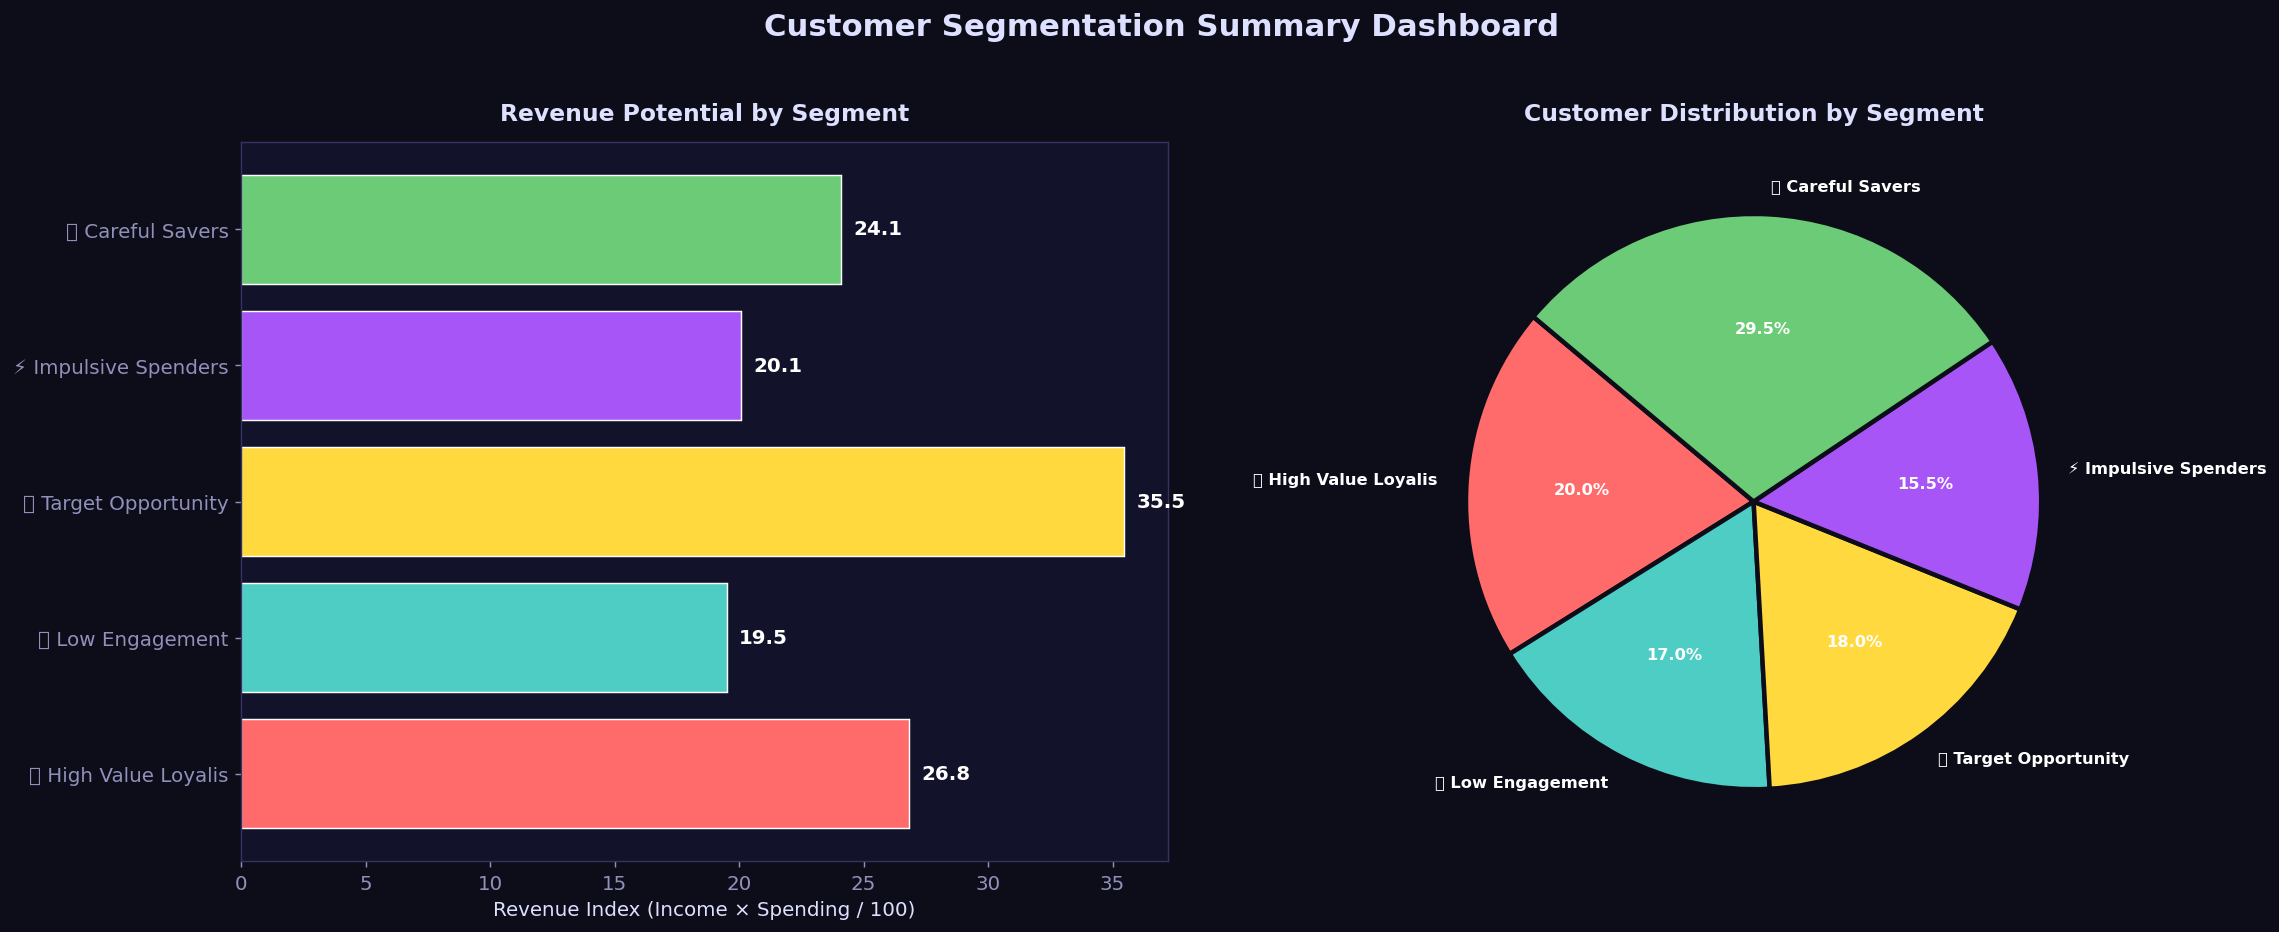

✅ Summary dashboard saved!

🎉 Task 2 Complete — Customer Segmentation Analysis Done!


In [ ]:
# ── Figure 5: Final Summary Dashboard ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Customer Segmentation Summary Dashboard',
             fontsize=17, fontweight='bold', color='#dde0ff', y=1.02)

# 1. Revenue potential by segment (size * spending score)
seg_revenue = df.groupby('Cluster').apply(
    lambda g: g['Annual Income (k$)'].mean() * g['Spending Score (1-100)'].mean() / 100
).rename('Revenue Index')
seg_labels = [name_map[c][:20] for c in sorted(df['Cluster'].unique())]
colors_seg = [CLUSTER_COLORS[c] for c in sorted(df['Cluster'].unique())]

bars = axes[0].barh(seg_labels, seg_revenue.sort_index().values,
                    color=colors_seg, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, seg_revenue.sort_index().values):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'{v:.1f}', va='center', fontsize=11, color='white', fontweight='bold')
axes[0].set_xlabel('Revenue Index (Income × Spending / 100)', fontsize=11)
axes[0].set_title('Revenue Potential by Segment', fontweight='bold', pad=12, fontsize=13)

# 2. Segment size pie chart
sizes = [cluster_profile.loc[c, 'Size'] for c in sorted(df['Cluster'].unique())]
wedge_props = {'edgecolor': '#0d0d1a', 'linewidth': 2.5}
axes[1].pie(sizes, labels=seg_labels, colors=colors_seg,
            autopct='%1.1f%%', wedgeprops=wedge_props,
            textprops={'color':'white', 'fontsize':9, 'fontweight':'bold'},
            startangle=140)
axes[1].set_title('Customer Distribution by Segment', fontweight='bold', pad=12, fontsize=13)

plt.tight_layout()
plt.savefig('task2_summary_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Summary dashboard saved!')
print('\n🎉 Task 2 Complete — Customer Segmentation Analysis Done!')